<a href="https://colab.research.google.com/github/sydas13/ML_Lab_Codes/blob/main/Question13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [68]:
from google.colab import files

In [69]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [70]:
uploaded = files.upload()

Saving customers.csv to customers (3).csv


In [71]:
df = pd.read_csv("customers.csv")
df.columns = df.columns.str.strip()
X = df[['Age','Annual Income (k$)','Spending Score (1-100)']].values
X_scaled = StandardScaler().fit_transform(X)

In [72]:
kmeans = KMeans(n_clusters=5, random_state=42)
labels_euc = kmeans.fit_predict(X_scaled)

In [73]:
kmeans_euclidean = KMeans(n_clusters=5, random_state=42)
labels_euclidean = kmeans_euclidean.fit_predict(X_scaled)

In [74]:
# --- Manhattan “K-Medoids” style ---
def kmedoids_manhattan(X, k, max_iter=100):
    m = X.shape[0]
    medoid_ids = np.random.choice(m, k, replace=False)
    for _ in range(max_iter):
        # assign each point to nearest medoid
        dist = cdist(X, X[medoid_ids], metric='cityblock')
        labels = np.argmin(dist, axis=1)
        # recompute medoids
        new_medoids = np.copy(medoid_ids)
        for i in range(k):
            cluster_points = np.where(labels == i)[0]
            if len(cluster_points) == 0: continue
            intra_dists = cdist(X[cluster_points], X[cluster_points], metric='cityblock')
            new_medoids[i] = cluster_points[np.argmin(intra_dists.sum(axis=1))]
        if np.all(new_medoids == medoid_ids):
            break
        medoid_ids = new_medoids
    return labels, medoid_ids

labels_man, medoid_ids = kmedoids_manhattan(X_scaled, 5)

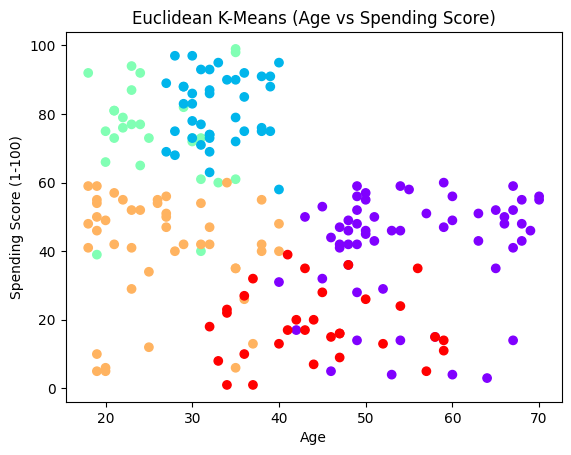

In [75]:
plt.scatter(X[:,0], X[:,2], c=labels_euc, cmap='rainbow')
plt.title("Euclidean K-Means (Age vs Spending Score)")
plt.xlabel("Age"); plt.ylabel("Spending Score (1-100)")
plt.show()

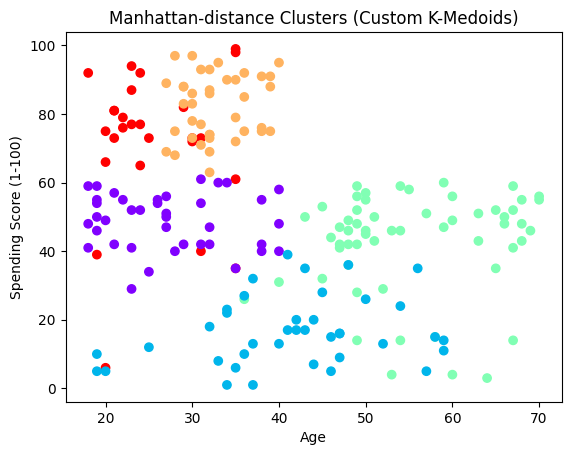

In [76]:
plt.scatter(X[:,0], X[:,2], c=labels_man, cmap='rainbow')
plt.title("Manhattan-distance Clusters (Custom K-Medoids)")
plt.xlabel("Age"); plt.ylabel("Spending Score (1-100)")
plt.show()


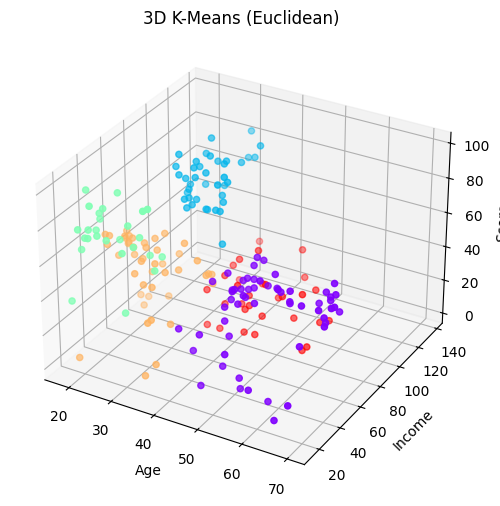

In [77]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X[:,0], X[:,1], X[:,2], c=labels_euc, cmap='rainbow')
ax.set_title("3D K-Means (Euclidean)")
ax.set_xlabel("Age"); ax.set_ylabel("Income"); ax.set_zlabel("Score")
plt.show()

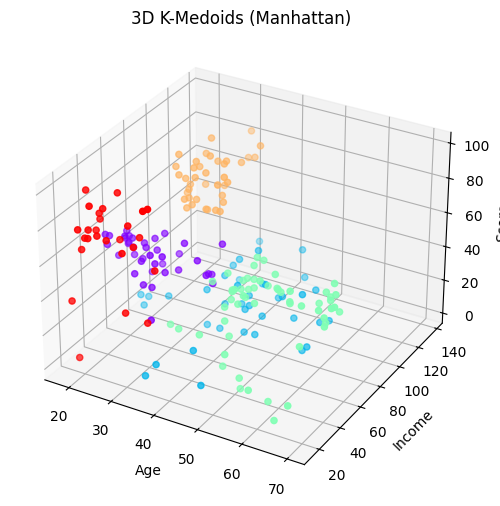

In [78]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X[:,0], X[:,1], X[:,2], c=labels_man, cmap='rainbow')
ax.set_title("3D K-Medoids (Manhattan)")
ax.set_xlabel("Age"); ax.set_ylabel("Income"); ax.set_zlabel("Score")
plt.show()